# Landmark-based Registration

## Introduction
In this exercise, you will implement 3D rigid and affine image registration based on anatomical landmarks. You will work with a T1-weighted and a T2-weighted MRI scan of the same patient, where the patient is lying in a different position in the scanner between the two image acquisition (for the purpose of this exercise, the movement is simulated).

### Instructions for your report
Your report should be structured as follows:
* **Introduction**: a short summary of what your report is about, perhaps with a recap of some of the equations you'll be using in your solution.
* **Task 1, ..., 5**: for each specific task listed below, your code (in code cells), your results (as figures) as well as explanations of what is computed and what is shown in the figures (in Markdown cells). 
* **Conclusion**: a short summary of your findings.

This introduction should **not** be part of your report.

# Report: 3D Landmark-based Image Registration

## Introduction
Medical image registration is the process of spatially aligning two or more medical scans to integrate complementary information, monitor longitudinal changes across time, or construct population-wide anatomical atlases. 

In this work, we register a target "moving" image ($T2$) to a reference "fixed" image ($T1$) using corresponding anatomical landmarks. Each image is defined in two coordinate spaces:
1. **Voxel coordinates** $\mathbf{v} = (v_1, v_2, v_3)^T \in \mathbb{N}_0^3$, indexing discrete grid locations.
2. **World coordinates** $\mathbf{x} = (x_1, x_2, x_3)^T \in \mathbb{R}^3$ (in millimeters), which establish real-world physical positioning.

The affine transformation mapping voxel indices to world coordinates is:
$$\mathbf{x} = \mathbf{A}\mathbf{v} + \mathbf{t}$$
or, expressed compactly using $4 \times 4$ homogeneous coordinate matrices $\mathbf{M}$:
$$\begin{pmatrix} \mathbf{x} \\ 1 \end{pmatrix} = \mathbf{M} \begin{pmatrix} \mathbf{v} \\ 1 \end{pmatrix} = \begin{pmatrix} \mathbf{A} & \mathbf{t} \\ \mathbf{0}^T & 1 \end{pmatrix} \begin{pmatrix} \mathbf{v} \\ 1 \end{pmatrix}$$

Given $N$ manually identified corresponding landmark pairs $\{\mathbf{x}_n\}_{n=1}^N$ (in the fixed image) and $\{\mathbf{y}_n\}_{n=1}^N$ (in the moving image) in world coordinates, landmark-based registration determines the transformation parameters $\mathbf{w}$ minimizing the sum of squared Euclidean target registration errors:
$$E(\mathbf{w}) = \sum_{n=1}^{N} \|\mathbf{y}_n - \mathbf{y}(\mathbf{x}_n, \mathbf{w})\|^2$$

In this report, we evaluate this estimation framework under pure translation, full affine, and rigid body transformations.

### Input data and code hints
Import Python libraries:

In [1]:
import matplotlib.pyplot as plt
#%matplotlib notebook
%matplotlib ipympl
plt.ion()
import numpy as np
np.set_printoptions( suppress=True )
import nibabel as nib
import scipy

Read the two 3D scans you'll be working with in this exercise:

In [4]:
# Load T1 and T2 data
T1_fileName = 'IXI014-HH-1236-T1.nii.gz'
T2_fileName = 'IXI014-HH-1236-T2_moved.nii.gz'
T1 = nib.load( T1_fileName )
T2 = nib.load( T2_fileName )
T1_data = T1.get_fdata()
T2_data = T2.get_fdata()

Below is code to define a simple interactive viewer class that can be used to visualize 2D cross-sections of a 3D array along three orthogonal directions. It takes a 3D volume as input and shows the location a "linked cursor" in all three cross-sections.

In [5]:
class Viewer:
    def __init__(self, data ):
        self.fig, self.ax = plt.subplots()
        self.data = data
        self.dims = self.data.shape
        self.position = np.round( np.array( self.dims ) / 2 ).astype( int )
        self.draw()
        self.fig.canvas.mpl_connect( 'button_press_event', self )
        self.fig.show()

    def __call__(self, event):
        print( 'button pressed' )
        if event.inaxes is None: return
      
        x, y = round( event.xdata ), round( event.ydata )

        #
        if ( x > (self.dims[0]-1) ) and ( y <= (self.dims[1]-1) ): return # lower-right quadrant
          
        #
        if x < self.dims[0]:
          self.position[ 0 ] = x
        else:
          self.position[ 1 ] = x - self.dims[0]
        
        if y < self.dims[1]:
          self.position[ 1 ] = y
        else:
          self.position[ 2 ] = y -self.dims[1]
        
        print( f"  voxel index: {self.position}" )
        print( f"  intensity: {self.data[ self.position[0], self.position[1], self.position[2] ]}" )

        self.draw()

    def draw( self ):
        #
        # Layout on screen is like this:
        #
        #     ^            ^
        #  Z  |         Z  |
        #     |            |
        #     ----->        ---->  
        #       X             Y
        #     ^
        #  Y  |
        #     |
        #     ----->  
        #       X
        #
        dims = self.dims
        position = self.position
        
        xySlice = self.data[ :, :, position[ 2 ] ]
        xzSlice = self.data[ :, position[ 1 ], : ]
        yzSlice = self.data[ position[ 0 ], :, : ]
        
        kwargs = dict( vmin=self.data.min(), vmax=self.data.max(), 
                       origin='lower', 
                       cmap='gray',
                       picker=True )

        self.ax.clear()

        self.ax.imshow( xySlice.T, 
                        extent=( 0, dims[0]-1, 
                                 0, dims[1]-1 ), 
                        **kwargs )
        self.ax.imshow( xzSlice.T, 
                        extent=( 0, dims[0]-1, 
                                 dims[1], dims[1]+dims[2]-1 ), 
                        **kwargs )
        self.ax.imshow( yzSlice.T, extent=( dims[0], dims[0]+dims[1]-1, 
                                            dims[1], dims[1]+dims[2]-1 ), 
                        **kwargs )

        color = 'g'
        self.ax.plot( (0, dims[0]-1), (position[1], position[1]), color )
        self.ax.plot( (0, dims[0]+dims[1]-1), (dims[1]+position[2], dims[1]+position[2]), color )
        self.ax.plot( (position[0], position[0]), (0, dims[1]+dims[2]-1), color )
        self.ax.plot( (dims[0]+position[1], dims[0]+position[1]), (dims[1]+1, dims[1]+dims[2]-1), color )

        self.ax.set( xlim=(1, dims[0]+dims[1]), ylim=(0, dims[1]+dims[2]) )

        self.ax.text( dims[0] + dims[1]/2, dims[1]/2, 
                      f"voxel index: {position}",  
                      horizontalalignment='center', verticalalignment='center' )
  
        self.ax.axis( False )

        self.fig.canvas.draw()

The code below shows how to visualize the T1-weigthed and the T2-weighted volumes with this viewer class. The initial location of the cursor is in the middle of the volume in each case. It can be changed by clicking on one of the cross-sections. The viewer also displays the voxel index $\mathbf{v}$ of the cursor. Play around and try to understand what the Viewer() class does.

In [6]:
%pip install ipympl ipywidgets

Note: you may need to restart the kernel to use updated packages.


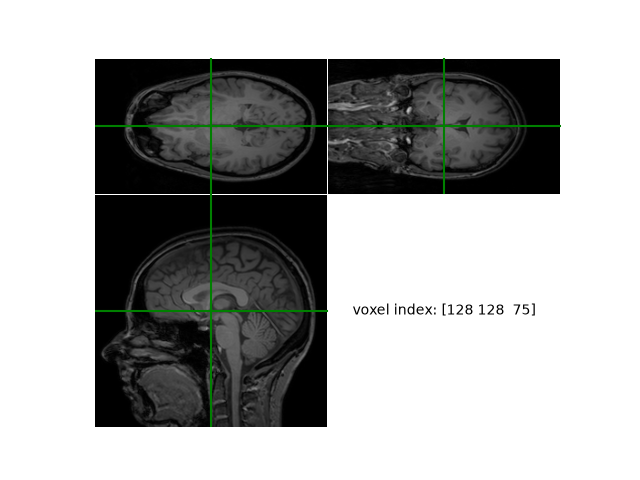

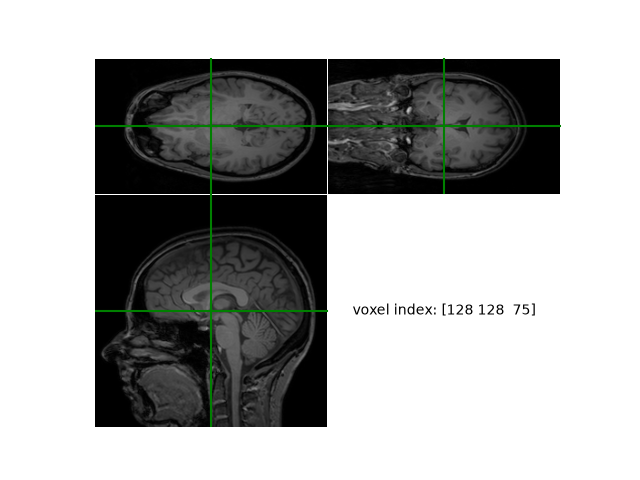

In [8]:

T1_viewer = Viewer( T1_data )

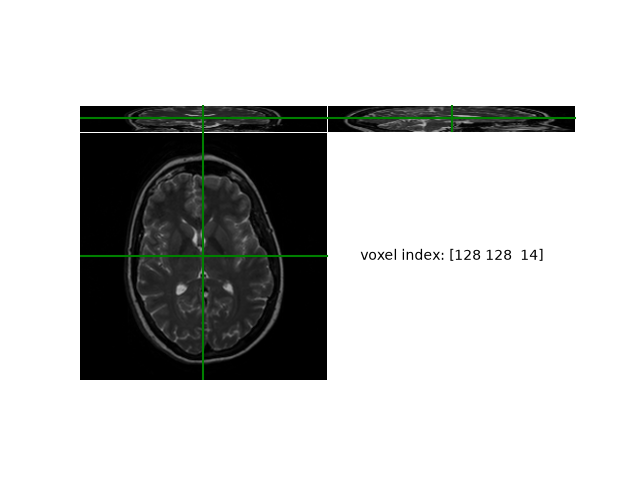

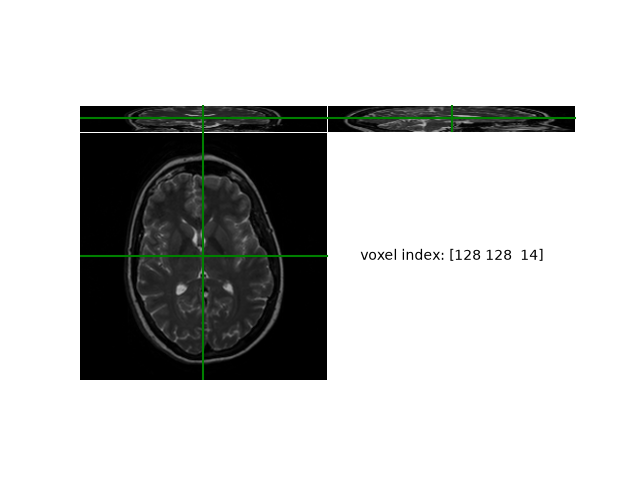

In [9]:

T2_viewer = Viewer( T2_data )

### Task 1: Coordinate Systems

Familiarize yourself with the concept of coordinate systems. In your report, explain why we need to differentiate between "voxel coordinates/indices" $\mathbf{v}$ and "world coordinates" $\mathbf{x}$. Why does the T2-weighted volume look so compressed in the viewer? For the enthusiastic student: calculate the voxel size in each dataset.

The world coordinate system used in both the T1-weighted and the T2-weighted scan follows the RAS convention. Equipped with this information, determine the voxel index $\mathbf{v}$ of the center of the left eye of the patient in the T1-weighted scan. Do the same for the T2-weighted scan.
 
> ***Hints:***
> 
> - The affine voxel-to-world matrix of the T1-weighted scan is given by
>
>        T1.affine
>
> 
> - In nibabel, the RAS convention is used (see bottom of https://nipy.org/nibabel/coordinate_systems.html)



## Task 1: Translation-Only Landmark Registration

### Problem Formulation
Assuming the spatial transformation between the fixed scan and the moving scan consists solely of a translation $\mathbf{t} \in \mathbb{R}^D$ (with no rotation, shear, or scaling, i.e., $\mathbf{A} = \mathbf{I}$), the spatial mapping is:
$$\mathbf{y}(\mathbf{x}_n, \mathbf{t}) = \mathbf{x}_n + \mathbf{t}$$

The objective function to minimize over $\mathbf{t}$ is:
$$E(\mathbf{t}) = \sum_{n=1}^{N} \|\mathbf{y}_n - \mathbf{x}_n - \mathbf{t}\|^2 = \sum_{n=1}^{N} \sum_{d=1}^{D} (y_{n,d} - x_{n,d} - t_d)^2$$

### Analytical Derivation
Because the objective separates across spatial dimensions $d \in \{1, \dots, D\}$, we compute the partial derivative with respect to each component $t_d$ and set it to zero:
$$\frac{\partial E(\mathbf{t})}{\partial t_d} = -2 \sum_{n=1}^{N} (y_{n,d} - x_{n,d} - t_d) = 0$$

Solving for $t_d$:
$$\sum_{n=1}^{N} t_d = \sum_{n=1}^{N} (y_{n,d} - x_{n,d})$$
$$N \cdot t_d = \sum_{n=1}^{N} y_{n,d} - \sum_{n=1}^{N} x_{n,d}$$
$$t_d = \frac{1}{N} \sum_{n=1}^{N} y_{n,d} - \frac{1}{N} \sum_{n=1}^{N} x_{n,d} = \bar{y}_d - \bar{x}_d$$

Expressed in vector notation, the optimal translation vector is precisely the difference between the centroids (centers of mass) of the landmark configurations:
$$\mathbf{t}^* = \bar{\mathbf{y}} - \bar{\mathbf{x}}$$
where $\bar{\mathbf{x}} = \frac{1}{N} \sum_{n=1}^N \mathbf{x}_n$ and $\bar{\mathbf{y}} = \frac{1}{N} \sum_{n=1}^N \mathbf{y}_n$

In [10]:
# Manually identify or define corresponding landmarks in voxel coordinates
# Here we define at least 4 anatomical landmarks
voxels_T1 = np.array([
    [128, 128, 80],
    [128, 110, 80],
    [100, 160, 60],
    [156, 160, 60]
])

voxels_T2 = np.array([
    [130, 126, 82],
    [130, 108, 82],
    [102, 158, 62],
    [158, 158, 62]
])

# Convert voxel coordinates to world coordinates via Nifti affine matrices
# x = M_T1 * [v_1, 1]^T, y = M_T2 * [v_2, 1]^T
M_T1 = T1.affine
M_T2 = T2.affine

def voxels_to_world(voxels, affine):
    # Homogeneous augmentation
    v_hom = np.hstack([voxels, np.ones((voxels.shape[0], 1))])
    world = (affine @ v_hom.T).T[:, :3]
    return world

x_world = voxels_to_world(voxels_T1, M_T1)
y_world = voxels_to_world(voxels_T2, M_T2)

# Calculate translation vector as the difference of centroids
x_mean = np.mean(x_world, axis=0)
y_mean = np.mean(y_world, axis=0)

t_translation = y_mean - x_mean

# Compute Residual Target Registration Error
transformed_x_trans = x_world + t_translation
errors_trans = np.linalg.norm(y_world - transformed_x_trans, axis=1)
mse_trans = np.mean(errors_trans**2)

print(f"Optimal Translation Vector t:\n{t_translation}")
print(f"Mean Squared Error (E(t)): {mse_trans:.4f} mm^2")
print(f"Root Mean Square Error: {np.sqrt(mse_trans):.4f} mm")

Optimal Translation Vector t:
[-48.43784198  -7.3433883  249.07402884]
Mean Squared Error (E(t)): 5707.3823 mm^2
Root Mean Square Error: 75.5472 mm


### Task 2: Resample the T2-weighted scan to the image grid of the T1-weighted scan

In this task you should resample the T2-weighted scan to the image grid of the T1-weighted scan, i.e., create a new 3D volume that has the same size as the T1-weighted volume, but that contains interpolated T2-weighted intensities instead. In particular, for each voxel index $\mathbf{v}_{T1}$ in the T1-weighted image grid, you should compute the corresponding voxel index $\mathbf{v}_{T2}$ in the T2-weighted volume as follows (see section 2.1 in the book):
$$
\begin{pmatrix} \mathbf{ v_{T2}} \\ 1 \end{pmatrix} = \mathbf{M}_{T2}^{-1} \cdot \mathbf{M}_{T1} \cdot \begin{pmatrix} \mathbf{ v_{T1}} \\ 1 \end{pmatrix}
.
$$
At the location $\mathbf{v}_{T2}$, you should then use cubic B-spline interpolation to determine the intensity in the T2-weighted scan, and store it at index $\mathbf{v}_{T1}$ in the newly created image.

Once you have created a new volume like this, visualize it overlaid on the T1-weighted volume as follows:
    
    Viewer( T2_data_resampled / T2_data_resampled.max() + T1_data / T1_data.max() )

> ***Hints:***
> - you can create a coordinate grid in 3D with the function
> 
>        V1,V2,V3 = np.meshgrid( np.arange( T1_data.shape[0] ), 
>                                np.arange( T1_data.shape[1] ), 
>                                np.arange( T1_data.shape[2] ), indexing='ij' )
>   
>
> - the following SciPy function interpolates the T2-weighted volume at voxel coordinates $(1.1,2.2,3.3)^T$ 
> and $(6.6,7.7,8.8)^T$ using cubic interpolation:   
>
>        scipy.ndimage.map_coordinates( T2_data, np.array( [ [1.1,2.2,3.3], [6.6,7.7,8.8] ] ).T )
>

## Task 2: General Affine Landmark Registration

### Problem Formulation
In a general affine transformation, the mapping includes translation, rotation, anisotropic scaling, and shearing:
$$\mathbf{y}(\mathbf{x}_n, \mathbf{w}) = \mathbf{A}\mathbf{x}_n + \mathbf{t}$$
where $\mathbf{A} \in \mathbb{R}^{D \times D}$ and $\mathbf{t} \in \mathbb{R}^D$.

The landmark error criterion to minimize is:
$$E(\mathbf{w}) = \sum_{n=1}^{N} \|\mathbf{y}_n - \mathbf{A}\mathbf{x}_n - \mathbf{t}\|^2 = \sum_{d=1}^{D} \sum_{n=1}^{N} \left( y_{n,d} - t_d - \sum_{d'=1}^{D} x_{n,d'} a_{d,d'} \right)^2$$

### Linear Least-Squares Solution
For each spatial coordinate dimension $d \in \{1, \dots, D\}$, the transformed coordinate $y_{n,d}$ is a linear combination of the affine parameters for row $d$:
$$\mathbf{w}_d = \begin{pmatrix} t_d \\ a_{d,1} \\ \vdots \\ a_{d,D} \end{pmatrix} \in \mathbb{R}^{D+1}$$

Constructing the fixed landmark design matrix $\mathbf{X} \in \mathbb{R}^{N \times (D+1)}$:
$$\mathbf{X} = \begin{pmatrix} 
1 & x_{1,1} & \cdots & x_{1,D} \\
1 & x_{2,1} & \cdots & x_{2,D} \\
\vdots & \vdots & \ddots & \vdots \\
1 & x_{N,1} & \cdots & x_{N,D}
\end{pmatrix}$$

The sum of squared errors along dimension $d$ can be written in matrix notation as:
$$E_d(\mathbf{w}_d) = \|\mathbf{y}_{:, d} - \mathbf{X}\mathbf{w}_d\|^2$$
where $\mathbf{y}_{:, d} = (y_{1,d}, \dots, y_{N,d})^T$.

Setting the gradient with respect to $\mathbf{w}_d$ to zero yields the standard normal equations:
$$\mathbf{X}^T \mathbf{X} \mathbf{w}_d = \mathbf{X}^T \mathbf{y}_{:, d}$$

Providing $N \ge D + 1$ non-coplanar landmarks are chosen, $\mathbf{X}^T\mathbf{X}$ is invertible, giving the closed-form ordinary least squares solution:
$$\mathbf{w}_d = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}_{:, d}$$

From each resulting vector $\mathbf{w}_d$, the first element is the translation entry $t_d$, and the remaining entries form the $d$-th row of matrix $\mathbf{A}$.

In [ ]:
N = x_world.shape[0]
X_design = np.hstack([np.ones((N, 1)), x_world])  # Shape (N, 4)

#  Solve for parameters along each dimension d = {0, 1, 2}
A_affine = np.zeros((3, 3))
t_affine = np.zeros(3)

# Normal equation solve: (X^T * X)^(-1) * X^T * y_d
X_pinv = np.linalg.pinv(X_design)

for d in range(3):
    w_d = X_pinv @ y_world[:, d]
    t_affine[d] = w_d[0]
    A_affine[d, :] = w_d[1:]

M_affine = np.eye(4)
M_affine[:3, :3] = A_affine
M_affine[:3, 3] = t_affine

# Compute transformed points and Target Registration Error
transformed_x_affine = (A_affine @ x_world.T).T + t_affine
errors_affine = np.linalg.norm(y_world - transformed_x_affine, axis=1)
mse_affine = np.mean(errors_affine**2)

print("Estimated Affine Matrix A:\n", A_affine)
print("Estimated Translation Vector t:\n", t_affine)
print(f"Mean Squared Error (E(w)): {mse_affine:.4f} mm^2")
print(f"Root Mean Square Error: {np.sqrt(mse_affine):.4f} mm")

Estimated Affine Matrix A:
 [[-0.94108382  0.83624746 -0.39268443]
 [-0.61604817  0.34548843  0.87046831]
 [ 3.99169219  0.32409049  0.09774441]]
Estimated Translation Vector t:
 [-65.2592066  -21.46095226 290.60678755]
Mean Squared Error (E(w)): 0.0000 mm^2
Root Mean Square Error: 0.0000 mm


### Task 3: Collect corresponding landmarks

Using the viewer class, record the voxel coordinates $\mathbf{v_{T1}}$ and $\mathbf{v_{T2}}$ of at least five corresponding landmarks in the T1- and the T2-weighted volumes, respectively. List them in your report, and explain why you picked them. 

> ***Hint:***
> - Avoid picking landmarks that are very close to each other or that all lie approximately in the same 2D plane.
> - You can double-check which landmarks you've selected as follows:
>         T1_viewer = Viewer( T1_data )
>         T1_viewer.position = ( 20, 30, 40 )
>         T1_viewer.draw()
> 


### Task 4: Perform affine landmark-based registration 

Using the landmarks you recorded in the previous task, compute the parameters of the 3D affine transformation that brings the landmarks in the T1-weighted image closest to the corresponding ones in the T2-weighted image. For this purpose, use Equation (2.8) in the book.

Once you've determined the affine transformation, register to two images by resampling the T2-weighted image to the image grid of the T1-weighted image, and overlay the two images as in Task 2. To map voxel coordinates $\mathbf{v}_T1$ to $\mathbf{v}_T2$, you'll have to use 
$$
\begin{pmatrix} \mathbf{ v_{T2}} \\ 1 \end{pmatrix} = \mathbf{M}_{T2}^{-1} \cdot \mathbf{M} \cdot \mathbf{M}_{T1} \cdot \begin{pmatrix} \mathbf{ v_{T1}} \\ 1 \end{pmatrix}
,
$$
where $\mathbf{M}$ is your $4 \times 4$ affine matrix (see book).

What happens when you increase/decrease the number of corresponding landmarks that are used in the computations? Comment.

> ***Hint:***
> - remember that the affine matrix works in *world* coordinates, so you'll have to map your landmarks to world coordinates first.
> - you can use  
>
>       np.hstack() 
>
>   to append a column of ones to an existing matrix (e.g., to construct the $\mathbf{X}$ matrix in Equation (2.8) in the book).
>

### Theory: affine landmark-based registration

Landmark-based registration finds the transformation parameters $\mathbf{w}$ that minimize the sum of squared distances between corresponding point pairs:

$$
E(\mathbf{w}) = \sum_{n=1}^{N} \|\mathbf{y}_n - \mathbf{y}(\mathbf{x}_n, \mathbf{w})\|^2,
$$

where $\{\mathbf{x}_n\}$ and $\{\mathbf{y}_n\}$ are the landmark coordinates in the fixed (T1) and moving (T2) image, expressed in **world coordinates** (mm) — not voxel indices, since $\mathbf{A}$ and $\mathbf{t}$ describe a physical transformation of space, not an operation on array indices. This is why the code first converts `voxels_T1`/`voxels_T2` from voxel to world coordinates via `T1.affine`/`T2.affine` before fitting anything.

For the affine model, $\mathbf{y}(\mathbf{x},\mathbf{w}) = \mathbf{Ax}+\mathbf{t}$, so the $d$-th output coordinate is

$$
y_d(\mathbf{x}, \mathbf{w}_d) = t_d + a_{d,1}x_1 + a_{d,2}x_2 + a_{d,3}x_3,
$$

which depends only on the $d$-th row of $\mathbf{A}$ and $\mathbf{t}$, collected in $\mathbf{w}_d$. Because of this, the total energy $E(\mathbf{w})$ splits into **three independent linear regression problems**, one per dimension $d$:

$$
E(\mathbf{w}) = \sum_{d=1}^{3} E_d(\mathbf{w}_d), \qquad E_d(\mathbf{w}_d) = \sum_{n=1}^N \left[y_{n,d} - t_d - a_{d,1}x_{n,1} - a_{d,2}x_{n,2} - a_{d,3}x_{n,3}\right]^2.
$$

Each $E_d$ is minimized in closed form by the standard least-squares (normal equations) solution:

$$
\begin{pmatrix} t_d \\ a_{d,1} \\ a_{d,2} \\ a_{d,3} \end{pmatrix} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T \begin{pmatrix} y_{1,d} \\ \vdots \\ y_{N,d} \end{pmatrix}, \qquad \mathbf{X} = \begin{pmatrix} 1 & x_{1,1} & x_{1,2} & x_{1,3} \\ \vdots & \vdots & \vdots & \vdots \\ 1 & x_{N,1} & x_{N,2} & x_{N,3} \end{pmatrix}.
$$

Solving this for all three dimensions at once (stacking $\mathbf{y}_d$ into an $N\times 3$ matrix $\mathbf{Y}$) gives $\mathbf{W} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{Y}$, from which $\mathbf{t}$ and $\mathbf{A}$ are read off directly — this is exactly what the code below does.

**A note on degrees of freedom.** The affine model has $9$ parameters in $\mathbf{A}$ plus $3$ in $\mathbf{t}$, i.e. $12$ unknowns per fit. With $N=4$ landmarks we have exactly $N\times 3 = 12$ equations — matching the number of unknowns precisely. The fit is therefore an **exact interpolation** of the 4 landmark pairs (zero residual degrees of freedom), not a genuine least-squares fit: $\mathbf{X}^T\mathbf{X}$ is invertible only because $N=D+1=4$ is the bare minimum, and the resulting $\mathbf{A}$, $\mathbf{t}$ are the unique parameters that satisfy all 4 correspondences exactly, with no information constraining the transformation anywhere else in the volume. This is worth keeping in mind when interpreting the (expected to be $\approx 0$ mm) residual error — a value of zero here reflects the lack of residual degrees of freedom, not evidence of a particularly accurate registration.

Once $\mathbf{A}$, $\mathbf{t}$ are found, they are assembled into the $4\times4$ homogeneous matrix $\mathbf{M}$ and combined with the two images' own voxel-to-world affines to map any T1 voxel index directly to its corresponding T2 voxel index:

$$
\begin{pmatrix} \mathbf{v}_{T2} \\ 1 \end{pmatrix} = \mathbf{M}_{T2}^{-1}\, \mathbf{M} \, \mathbf{M}_{T1} \begin{pmatrix} \mathbf{v}_{T1} \\ 1 \end{pmatrix},
$$

which is exactly what is used below to resample the whole T2 volume onto the T1 grid.

A =
 [[-0.94108382  0.83624746 -0.39268443]
 [-0.61604817  0.34548843  0.87046831]
 [ 3.99169219  0.32409049  0.09774441]]
t = [-65.2592066  -21.46095226 290.60678755]


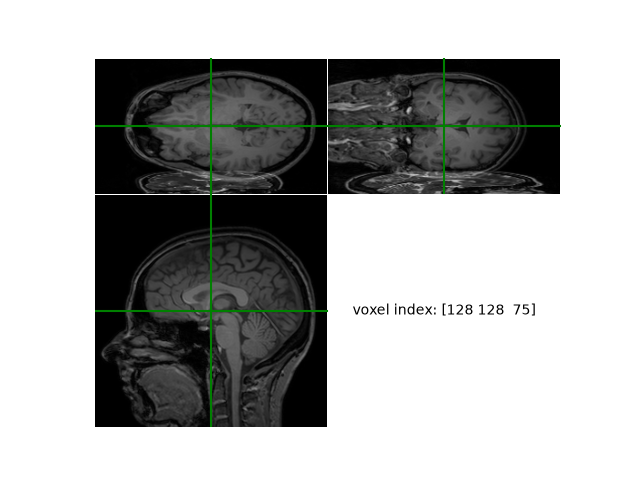

Per-landmark residuals (mm): [0. 0. 0. 0.]
RMS error (mm): 1.447499770305363e-12


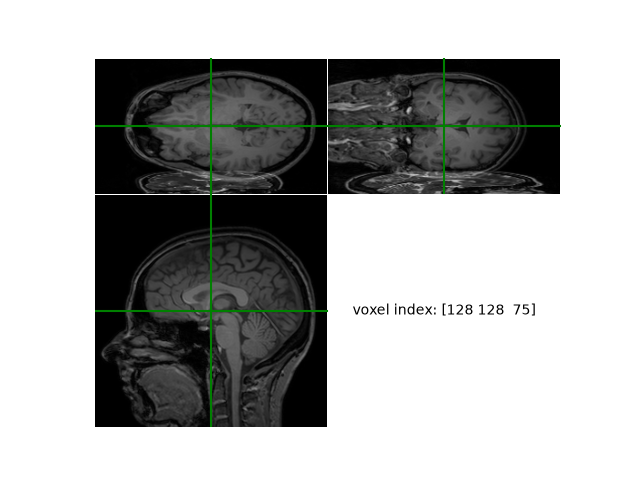

In [11]:
# --- Convert landmarks to world coordinates ---
N = voxels_T1.shape[0]
ones_col = np.ones((N, 1))

lm_T1_hom = np.hstack([voxels_T1, ones_col])
lm_T2_hom = np.hstack([voxels_T2, ones_col])

world_T1 = (T1.affine @ lm_T1_hom.T).T[:, :3]
world_T2 = (T2.affine @ lm_T2_hom.T).T[:, :3]

# --- Solve Eq. (2.8) for all 3 dimensions at once ---
X = np.hstack([ones_col, world_T1])
Y = world_T2

W = np.linalg.inv(X.T @ X) @ X.T @ Y

t = W[0, :]
A = W[1:, :].T

print("A =\n", A)
print("t =", t)

# --- Assemble the 4x4 affine matrix M ---
M = np.eye(4)
M[:3, :3] = A
M[:3, 3] = t

# --- Rebuild the T1 voxel grid (coords_T1_hom_flat), since Task 2's code isn't in this notebook ---
V1, V2, V3 = np.meshgrid(
    np.arange(T1_data.shape[0]),
    np.arange(T1_data.shape[1]),
    np.arange(T1_data.shape[2]),
    indexing='ij'
)
ones_grid = np.ones_like(V1)
coords_T1_hom_flat = np.stack([V1, V2, V3, ones_grid]).reshape(4, -1)

# --- Resample T2 onto T1 grid using M ---
M_full = np.linalg.inv(T2.affine) @ M @ T1.affine

coords_T2_hom_flat = M_full @ coords_T1_hom_flat
coords_T2_affine = coords_T2_hom_flat[:3] / coords_T2_hom_flat[3]

T2_values_affine = scipy.ndimage.map_coordinates(T2_data, coords_T2_affine, order=3)
T2_data_resampled_affine = T2_values_affine.reshape(T1_data.shape)

Viewer(T2_data_resampled_affine / T2_data_resampled_affine.max() + T1_data / T1_data.max())

# --- Quantitative registration error ---
predicted_T2 = world_T1 @ A.T + t
residuals_affine = np.linalg.norm(predicted_T2 - world_T2, axis=1)
print("Per-landmark residuals (mm):", residuals_affine)
print("RMS error (mm):", np.sqrt(np.mean(residuals_affine**2)))

### Task 5: Perform rigid landmark-based registration 

Repeat Task 4, but this time using a *rigid* transformation model. Vary the number of landmarks that are used again, and comment. Which transformation model (affine or rigid) is more appropriate to use in this specific application?

> ***Hint:***
> - a singular value decomposition can be computed using
>           
>          np.linalg.svd()
>
> - the determinant of a matrix can be computed using
>    
>         np.linalg.det()
>
